# Baked Food Nutrition Analysis

## About this file

It includes information on the comprehensive analysis of the nutritional composition of baked food items, capturing key metrics such as calories, proteins, carbohydrates, fats, fiber, sodium, etc.
It contains 656 records of clean data and 18 Columns.

Data source: [Baked Food Nutrition - Are You Eating Healthy? Exploring Nutrient Profiles of Baked Foods: Insights into Calories, Fats & More](https://www.kaggle.com/datasets/sandeep1080/baked-food-nutritions-check-are-you-healthy)

Column Descriptors:

| Column Name | Data Type | Description |
|---|---|---|
| Food | object | Name of the baked food item. |
| ProductType | object | Category or type of the baked food (e.g., bread, cake, cookies). |
| FlavorVariant | object | Specific flavor or variant of the baked food (e.g., chocolate, vanilla). |
| Calories-kcl | int64 | Total calories per serving, measured in kilocalories (kcl). |
| Protein-g | float64| Amount of protein per serving, measured in grams (g). |
| Carb-g | float64| Amount of carbohydrates per serving, measured in grams (g). |
| Fiber-g | float64| Amount of dietary fiber per serving, measured in grams (g). |
| Sugar-g | float64| Amount of sugar per serving, measured in grams (g). |
| Sodium-g | int64 | Amount of sodium per serving, measured in grams (g). |
| SaturatedFat-g | float64| Amount of saturated fat per serving, measured in grams (g). |
| MonounsaturatedFat-g | float64| Amount of monounsaturated fat per serving, measured in grams (g). |
| PolyunsaturatedFat-g | float64| Amount of polyunsaturated fat per serving, measured in grams (g). |
| TransFat-g | float64| Amount of trans fat per serving, measured in grams (g). |
| MeasureQuantity | float64| Quantity of the serving size (e.g., 1 slice, 1 piece). |
| MeasureType | object | Unit of measurement for the serving size (e.g., grams, ounces). |
| MQCalories-kcl | int64 | Calories per measured quantity, measured in kilocalories (kcl). |
| MQGmWt | float64| Weight of the measured quantity, measured in grams (g). |
| MQCalories100gm-kcl | int64 | Calories per 100 grams of the baked food, measured in kilocalories (kcl). |


In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
# Load the data
data = pd.read_csv("BakedFoodNutritions.csv")
data.head(n=10)

,Food,ProductType,FlavorVariant,Calories-kcl,Protein-g,Carb-g,Fiber-g,Sugar-g,Sodium-g,SaturatedFat-g,MonounsaturatedFat-g,PolyunsaturatedFat-g,TransaFat-g,MeasureQuantity,MeasureType,MQCalories-kcl,MQGmWt,MQCalories100gm-kcl
0,Andrea'S,Gluten Free Soft Dinner Roll,Prepared From Recipe,257,5.7,40.2,2.9,3.0,544,4.84,4.51,4.37,0.49,1.0,Roll,177,69.0,257
1,Archway,Home Style Cookies,Chocolate Chip Ice Box,497,4.3,65.0,2.0,34.1,270,8.10,8.90,1.40,5.83,1.0,Serving,119,24.0,497
2,Archway,Home Style Cookies,Coconut Macaroon,460,3.0,61.2,5.1,45.2,200,20.10,1.60,0.80,0.49,1.0,Serving,101,22.0,460
3,Archway,Home Style Cookies,Date Filled Oatmeal,400,4.7,68.2,2.1,34.3,331,2.80,4.80,1.10,3.36,1.0,Serving,100,25.0,400
4,Archway,Home Style Cookies,Dutch Cocoa,431,4.5,69.4,2.6,35.4,384,3.60,5.90,1.20,4.24,1.0,Serving,103,24.0,431
5,Archway,Home Style Cookies,Frosty Lemon,430,4.4,64.8,0.7,33.4,449,5.80,5.80,0.90,0.49,1.0,Serving,112,26.0,430
6,Archway,Home Style Cookies,Iced Molasses,420,3.5,69.1,1.0,38.4,605,4.20,4.80,2.40,3.08,1.0,Serving,118,28.0,420
7,Archway,Home Style Cookies,Iced Oatmeal,435,4.9,66.8,2.0,37.2,377,4.60,5.60,2.70,3.58,1.0,Serving,122,28.0,435
8,Archway,Home Style Cookies,Molasses,403,4.3,69.4,1.2,36.4,577,2.80,4.90,1.10,3.34,1.0,Serving,105,26.0,403
9,Archway,Home Style Cookies,Oatmeal,421,5.5,68.2,2.9,34.5,394,3.20,5.70,1.30,3.88,1.0,Serving,105,25.0,421


In [43]:
# Checking to empty values
data.isnull().sum()

Food                    0
ProductType             0
FlavorVariant           0
Calories-kcl            0
Protein-g               0
Carb-g                  0
Fiber-g                 0
Sugar-g                 0
Sodium-g                0
SaturatedFat-g          0
MonounsaturatedFat-g    0
PolyunsaturatedFat-g    0
TransaFat-g             0
MeasureQuantity         0
MeasureType             0
MQCalories-kcl          0
MQGmWt                  0
MQCalories100gm-kcl     0
dtype: int64

In [ ]:
# Split numeric and categorical columns
numeric_cols = data.select_dtypes(include=['int64', 'float64'])
# print(numeric_cols.shape)
categorical_cols = data.select_dtypes(include=['object'])
# print(categorical_cols.shape)

(656, 14)
(656, 4)


Distribution of Food. Number of samples: 656. Number of unique samples: 69
Distribution of ProductType. Number of samples: 656. Number of unique samples: 133
Distribution of FlavorVariant. Number of samples: 656. Number of unique samples: 305
Distribution of MeasureType. Number of samples: 656. Number of unique samples: 50


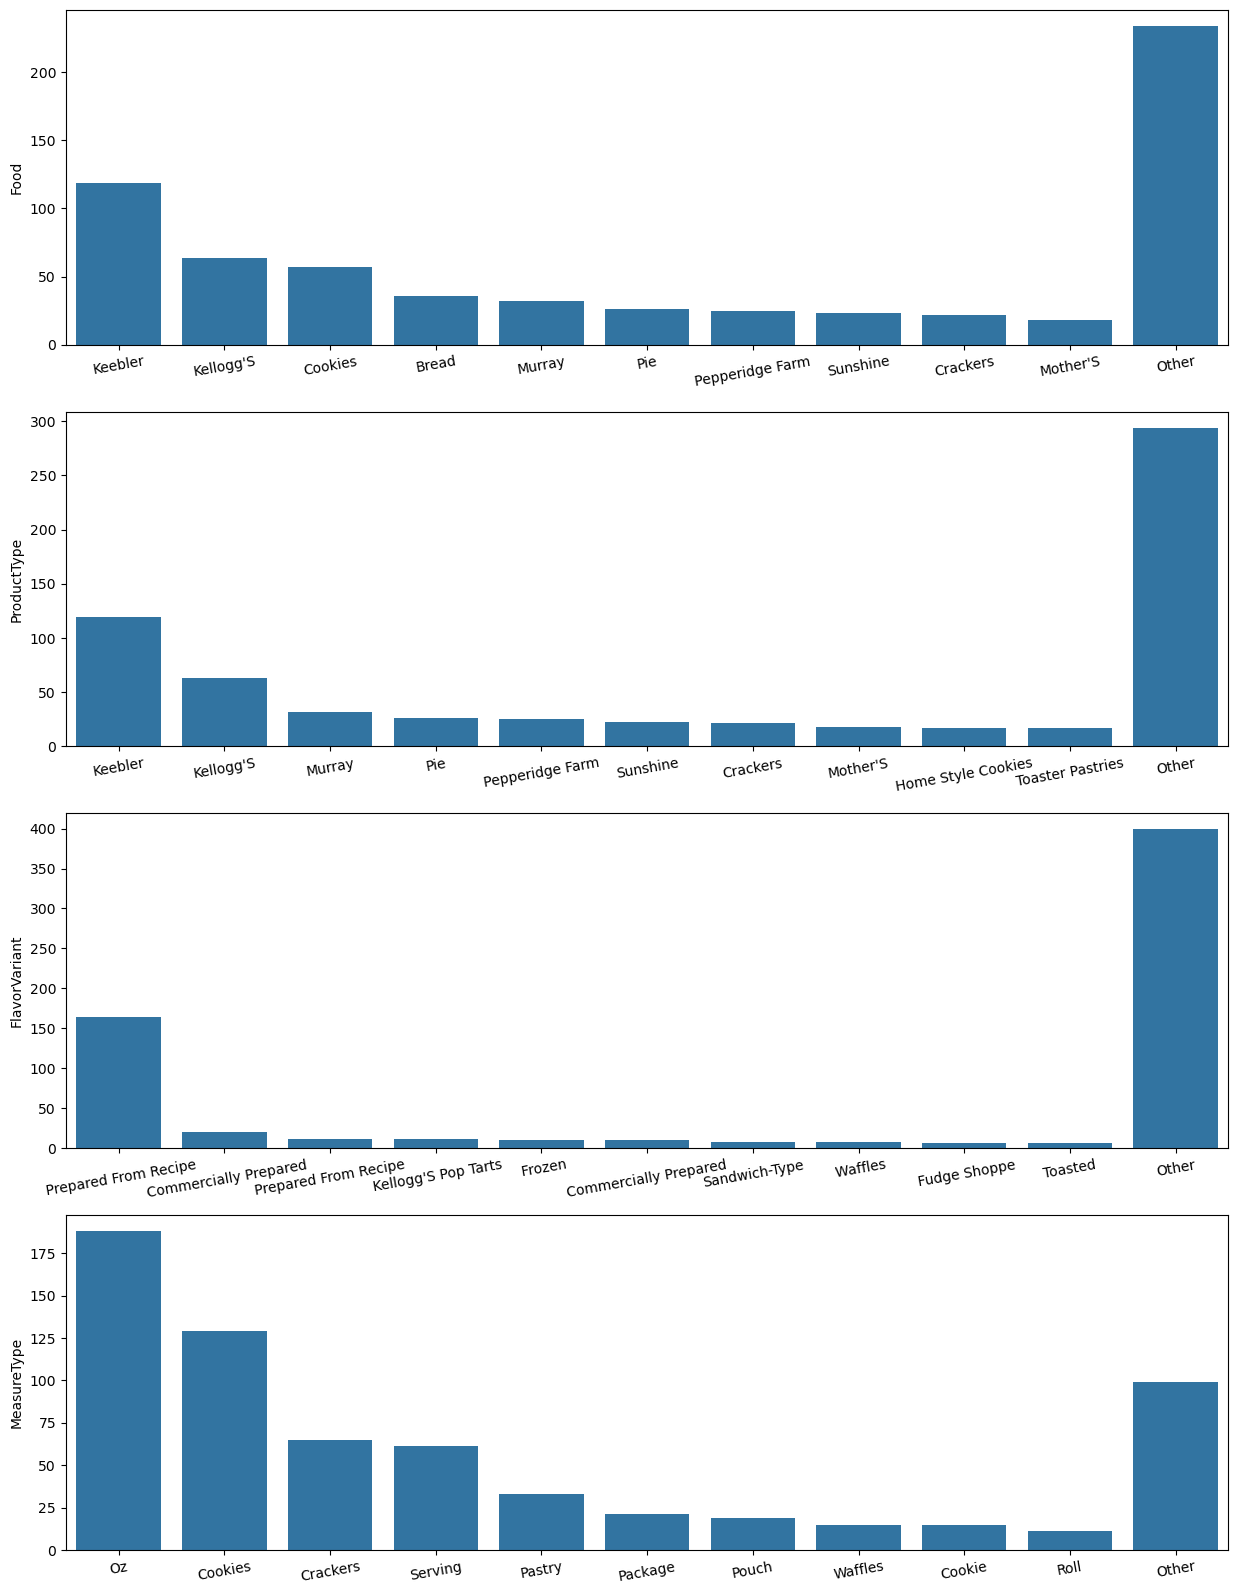

In [46]:
# See data distribution of each catergorical column
# Subplots all 4 catergorical columns
plt.figure(figsize=(15,20))
for index, col in enumerate(categorical_cols.columns):
    # compute top 20 values and others (sum of all other values)
    top_values = data[col].value_counts().nlargest(10)
    other = data[col].value_counts().sum() - top_values.sum()
    top_values = pd.concat([top_values, pd.Series([other], index=['Other'])])
    # plot the name of the top values on the y axis
    plt.subplot(4, 1, index + 1)
    sns.barplot(x=top_values.index, y=top_values.values)
    plt.xlabel(xlabel='')
    plt.xticks(rotation=10)
    # wrap long column names
    plt.ylabel(col, wrap=True)

    print(f"Distribution of {col}. Number of samples: {data[col].count()}. Number of unique samples: {data[col].nunique()}")
plt.show()

Distribution of Calories-kcl. Number of samples: 656. Number of unique samples: 272. Range: 51 to 562
Distribution of Protein-g. Number of samples: 656. Number of unique samples: 114. Range: 0.0 to 40.4
Distribution of Carb-g. Number of samples: 656. Number of unique samples: 338. Range: 20.8 to 87.7
Distribution of Fiber-g. Number of samples: 656. Number of unique samples: 108. Range: 0.0 to 26.9
Distribution of Sugar-g. Number of samples: 656. Number of unique samples: 304. Range: 0.0 to 57.4
Distribution of Sodium-g. Number of samples: 656. Number of unique samples: 405. Range: 0 to 10600
Distribution of SaturatedFat-g. Number of samples: 656. Number of unique samples: 151. Range: 0.0 to 24.7
Distribution of MonounsaturatedFat-g. Number of samples: 656. Number of unique samples: 126. Range: 0.0 to 21.6
Distribution of PolyunsaturatedFat-g. Number of samples: 656. Number of unique samples: 127. Range: 0.0 to 16.6
Distribution of TransaFat-g. Number of samples: 656. Number of unique s

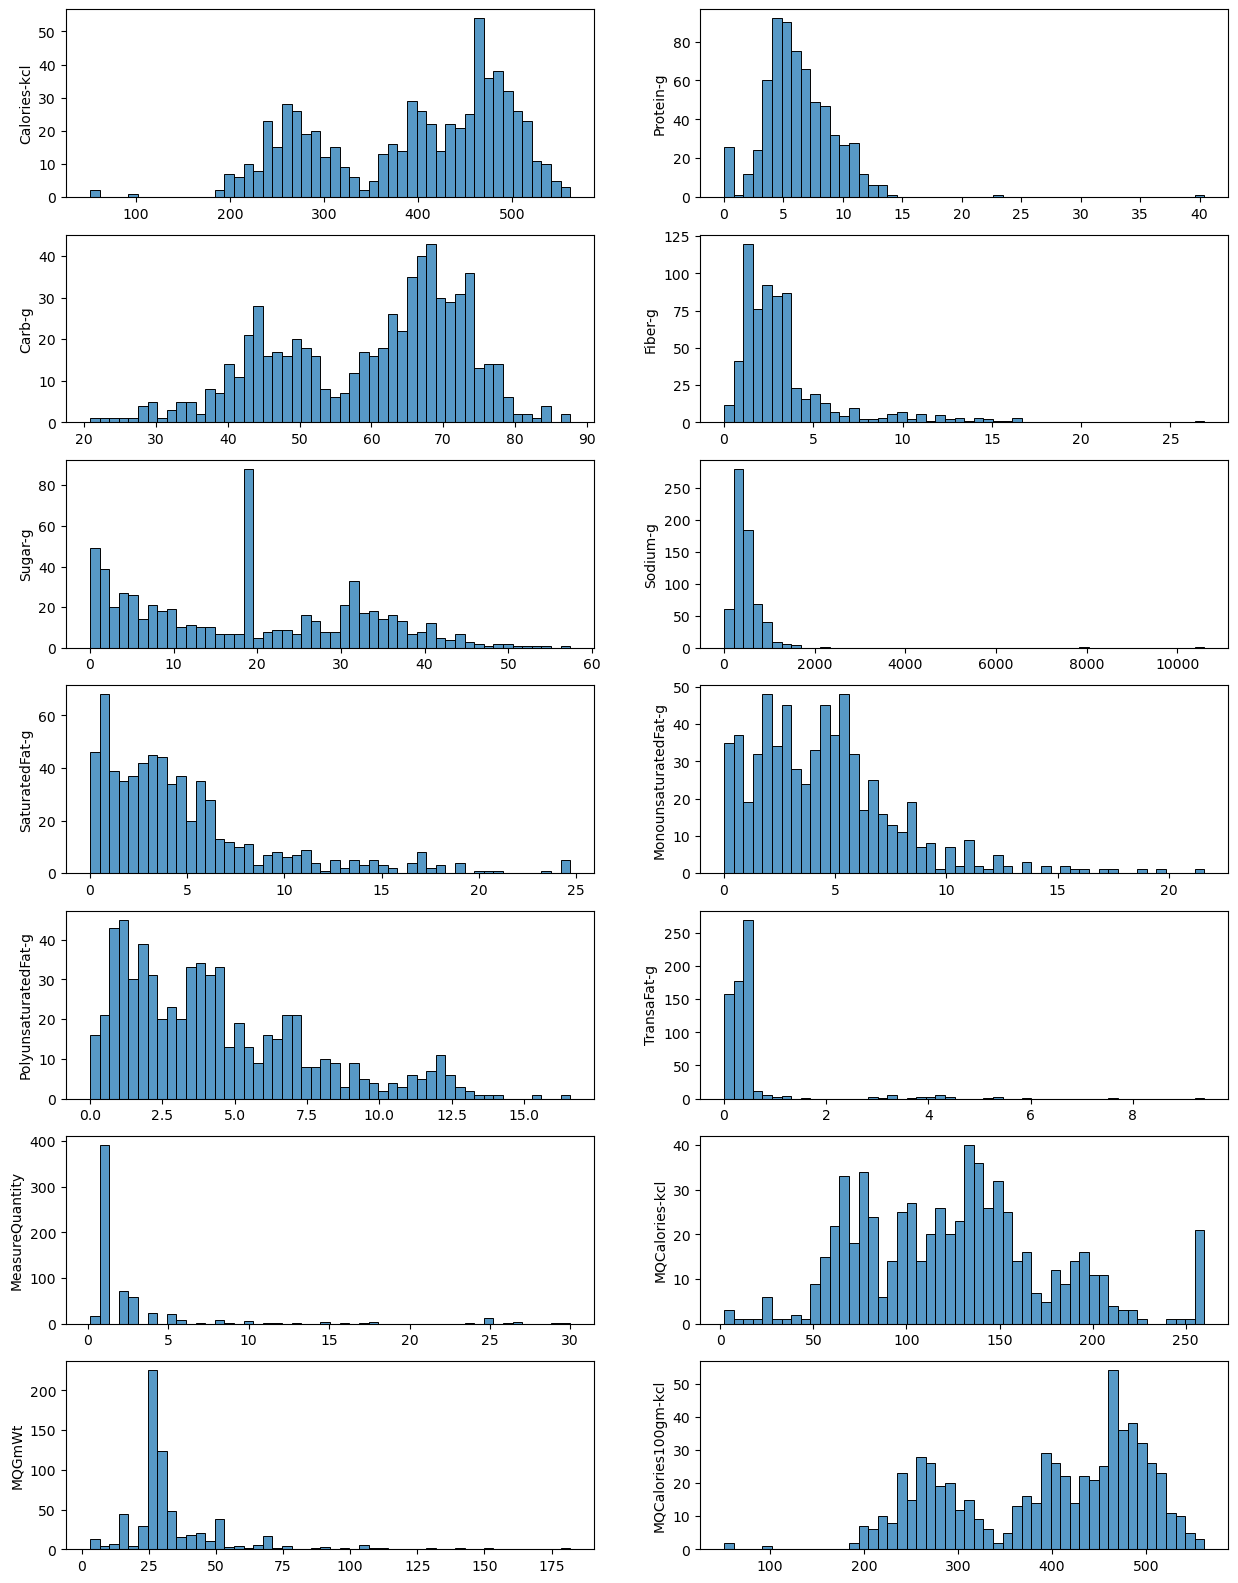

In [53]:
# See data distribution of each numeric column
plt.figure(figsize=(15,20))
for index, col in enumerate(numeric_cols):
    plt.subplot(7,2,index+1)
    sns.histplot(data[col], bins=50)
    plt.xlabel('')
    plt.ylabel(col, wrap=True)
    print(f"Distribution of {col}. Number of samples: {data[col].count()}. Number of unique samples: {data[col].nunique()}. Range: {data[col].min()} to {data[col].max()}")

plt.show()

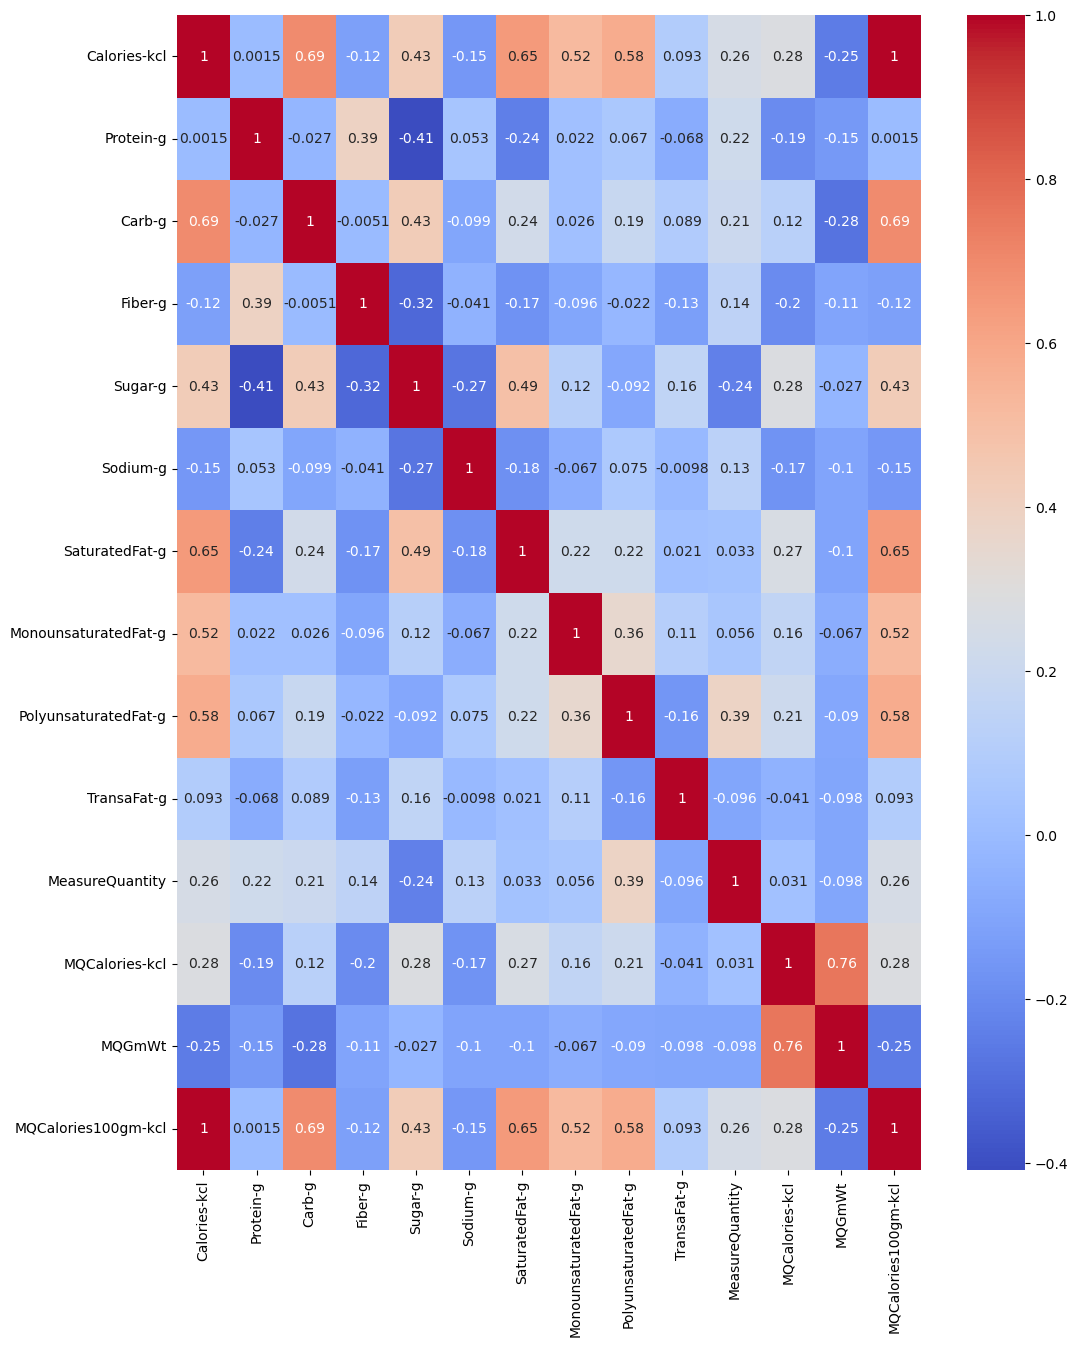

In [48]:
# See correlation between numeric columns
plt.figure(figsize=(12,15))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.show()

## Exploratory data visualization

The dataset has no missing values, so no need for artificial imputation. 


## General Questions
- What are the most and least calorie-dense baked foods?
- Which baked food has the highest and lowest sugar content?
- What are the most and least protein-rich baked foods?
- How does the nutritional profile vary between different product types (e.g., cookies vs. rolls)?
- Which baked foods have the highest fiber content?
## Comparative Analysis
- How do the calorie contents of different brands compare?
- What is the average sodium content across all baked foods?
- Are gluten-free products generally healthier in terms of sugar and fat content?
## Correlations & Trends
- Is there a correlation between sugar content and calorie count?
- Do foods with more fiber tend to have lower sugar content?
- How does fat composition (saturated vs. unsaturated) compare across different product types?
## Portion-Based Analysis
- How do the calorie and macronutrient values change when standardized per 100 grams?
- Are some serving sizes misleading in terms of calorie density?